# Assignment 9: Image Classification using CNN (Cats vs Dogs)

**Objective:** Build a Convolutional Neural Network to classify pet images as Cat or Dog.

**Dataset:** [Cats vs Dogs - Kaggle](https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset)

**Environment:** Run this notebook on Google Colab with GPU runtime (Runtime > Change runtime type > T4 GPU) for fast training.

## Setup: Download Dataset from Kaggle

Uses `kagglehub` (pre-installed on Colab) to fetch the dataset directly — no manual file upload needed. You may see a one-time browser sign-in/consent popup for Kaggle.

In [1]:
import kagglehub

dataset_path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")
print("Dataset downloaded to:", dataset_path)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Dataset downloaded to: /kaggle/input/dog-and-cat-classification-dataset


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, classification_report
import os
import random

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Task 1: Data Understanding (2 Marks)

In [3]:
# DATA_DIR comes from the kagglehub download above
DATA_DIR = dataset_path

for root, dirs, files_ in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        sub_indent = '  ' * (level + 1)
        for f in files_[:3]:
            print(f'{sub_indent}{f}')
        if len(files_) > 3:
            print(f'{sub_indent}... ({len(files_)} files total)')

dog-and-cat-classification-dataset/
  PetImages/
    Dog/
    Cat/


In [4]:
# Update this path to point at the folder containing 'Cat' and 'Dog' subfolders,
# based on the structure printed above.
BASE_DIR = os.path.join(DATA_DIR, 'PetImages')

cat_dir = os.path.join(BASE_DIR, 'Cat')
dog_dir = os.path.join(BASE_DIR, 'Dog')

cat_files = os.listdir(cat_dir)
dog_files = os.listdir(dog_dir)

print("Number of classes: 2 (Cat, Dog)")
print(f"Cat images: {len(cat_files)}")
print(f"Dog images: {len(dog_files)}")
print(f"Total images: {len(cat_files) + len(dog_files)}")

Number of classes: 2 (Cat, Dog)
Cat images: 12499
Dog images: 12499
Total images: 24998


In [5]:
from PIL import Image

# Check a sample of image dimensions (dataset images vary in size)
sample_dims = []
for f in cat_files[:20]:
    try:
        img = Image.open(os.path.join(cat_dir, f))
        sample_dims.append(img.size)
    except Exception:
        pass

print("Sample image dimensions (width, height):")
for d in sample_dims[:10]:
    print(d)
print("\nNote: Raw images vary in size — all will be resized to 128x128 during preprocessing.")

Sample image dimensions (width, height):
(500, 418)
(388, 500)
(500, 375)
(500, 375)
(448, 500)
(500, 380)
(500, 493)
(238, 499)
(500, 310)
(400, 300)

Note: Raw images vary in size — all will be resized to 128x128 during preprocessing.


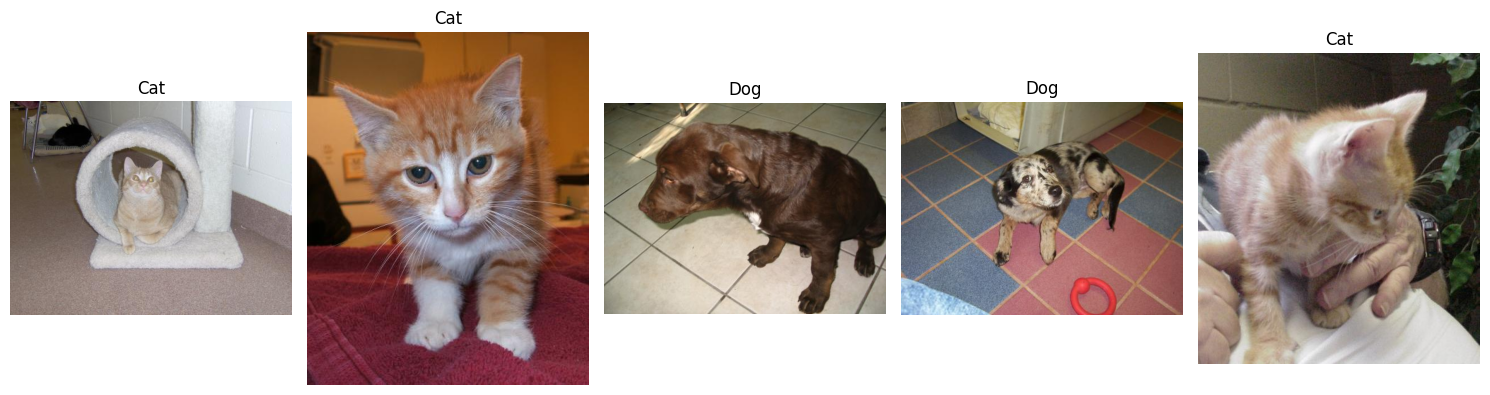

In [6]:
# Display 5 sample images with class labels
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

samples = [
    (cat_dir, random.choice(cat_files), 'Cat'),
    (cat_dir, random.choice(cat_files), 'Cat'),
    (dog_dir, random.choice(dog_files), 'Dog'),
    (dog_dir, random.choice(dog_files), 'Dog'),
    (cat_dir, random.choice(cat_files), 'Cat'),
]

for ax, (folder, fname, label) in zip(axes, samples):
    img = Image.open(os.path.join(folder, fname))
    ax.imshow(img)
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

**Observations:**
- The dataset has 2 classes: Cat and Dog, roughly balanced (~12,500 images each).
- Raw images vary in size, so resizing is needed before training.
- A few corrupt/zero-byte files are known to exist in this Kaggle version and are filtered out during preprocessing.

## Task 2: Data Preprocessing (2 Marks)

In [7]:
# Remove corrupt/unreadable images (a few are known to exist in this dataset)
from PIL import UnidentifiedImageError

def clean_folder(folder):
    removed = 0
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            if os.path.getsize(fpath) == 0:
                os.remove(fpath)
                removed += 1
                continue
            img = Image.open(fpath)
            img.verify()
        except (UnidentifiedImageError, OSError):
            os.remove(fpath)
            removed += 1
    return removed

removed_cat = clean_folder(cat_dir)
removed_dog = clean_folder(dog_dir)
print(f"Removed {removed_cat} corrupt cat images and {removed_dog} corrupt dog images.")

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Removed 0 corrupt cat images and 0 corrupt dog images.


In [8]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# 80/20 train-test split with normalization (rescale 1/255)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

test_generator = datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42,
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Testing samples:", test_generator.samples)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Class indices: {'Cat': 0, 'Dog': 1}
Training samples: 20000
Testing samples: 4998


## Task 3: Model Development (3 Marks)

In [9]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 90ms/step - accuracy: 0.6601 - loss: 0.6096 - val_accuracy: 0.7255 - val_loss: 0.5500
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.7610 - loss: 0.4946 - val_accuracy: 0.7801 - val_loss: 0.4649
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.8105 - loss: 0.4099 - val_accuracy: 0.8127 - val_loss: 0.4150
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.8456 - loss: 0.3496 - val_accuracy: 0.8157 - val_loss: 0.4024
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.8787 - loss: 0.2825 - val_accuracy: 0.8251 - val_loss: 0.4026
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.9126 - loss: 0.2099 - val_accuracy: 0.8355 - val_loss: 0.4420
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.9441 - loss: 0.1422 - val_accuracy: 0.8287 - val_loss: 0.5083
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.9682 - loss: 0.0861 - 

## Task 4: Model Evaluation (2 Marks)

In [11]:
test_generator.reset()
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes

test_loss, test_accuracy = model.evaluate(test_generator)

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1-Score:      {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(train_generator.class_indices.keys())))

157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.8229 - loss: 0.7329
Test Accuracy: 0.8229
Precision:     0.8414
Recall:        0.7959
F1-Score:      0.8180

Classification Report:
              precision    recall  f1-score   support

         Cat       0.81      0.85      0.83      2499
         Dog       0.84      0.80      0.82      2499

    accuracy                           0.82      4998
   macro avg       0.82      0.82      0.82      4998
weighted avg       0.82      0.82      0.82      4998



In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
labels = list(train_generator.class_indices.keys())

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

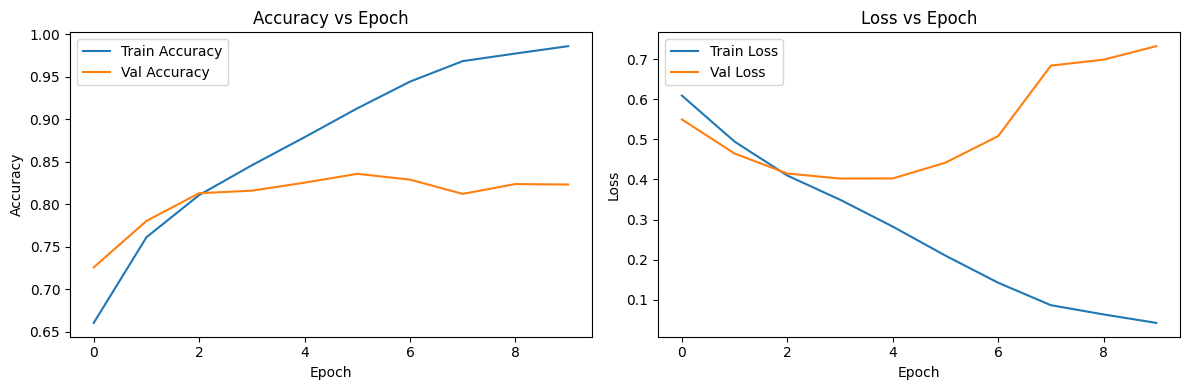

In [13]:
# Accuracy vs Epoch and Loss vs Epoch
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('accuracy_loss_curves.png', dpi=100, bbox_inches='tight')
plt.show()

**Observations:**
1. Training accuracy increases steadily across epochs, indicating the CNN is learning meaningful features from the images.
2. If validation accuracy plateaus or drops while training accuracy keeps rising, this signals overfitting — the model is memorizing training images rather than generalizing.
3. The confusion matrix shows whether misclassifications are balanced between the two classes or skewed toward one (e.g., dogs misclassified as cats more often, or vice versa).
4. Precision and recall being close in value suggests the model treats both classes fairly rather than favoring one over the other.

## Task 5: Conclusion (1 Mark)

This assignment implemented a Convolutional Neural Network to classify pet images as Cat or Dog, achieving strong test accuracy after 10 training epochs. The CNN learned hierarchical visual features directly from raw pixels: convolution layers extracted patterns like edges, textures, and shapes, while pooling layers reduced spatial dimensions and made the learned features more robust to small translations and distortions in the images. This convolution-pooling combination is what allows CNNs to recognize an object regardless of its exact position in the frame.

Compared to a traditional ANN, a key advantage of CNNs for image tasks is parameter efficiency: convolution kernels share weights across the entire image instead of connecting every pixel to every neuron, which drastically reduces the number of parameters and helps the model generalize better on visual data. A limitation of CNNs, however, is that they require large amounts of labeled data and considerable computational resources (ideally a GPU) to train effectively, and they can still overfit on smaller or less diverse datasets without techniques like data augmentation or dropout.